<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/ML_Models_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model performance analysis For 70:30 Split
1.Logistic Regression
2.K-Nearest Neighbors (KNN)
3.Decision Tree
4.Random Forest
5.Support Vector Machine (SVM)
6.Naive Bayes
7.Gradient Boosting
8.AdaBoost
9.Extra Trees
10.XGBoost
11.Linear Discriminant Analysis 12.Quadratic Discriminant Analysis






In [2]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

# The 12 Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

In [3]:
# --- STEP 1: MOUNT GOOGLE DRIVE ---
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- STEP 2: LOAD DATASET ---
file_path = '/content/drive/MyDrive/ML_datasets/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)

In [10]:
# --- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---
print("### Dataset Info ###")
print(df.info())

print("\n### Missing Values ###")
print(df.isnull().sum())

print(df.head())



### Dataset Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

### Missing Values ###
id                     0
gender                 0
age                    0
hypertension           0
heart_d

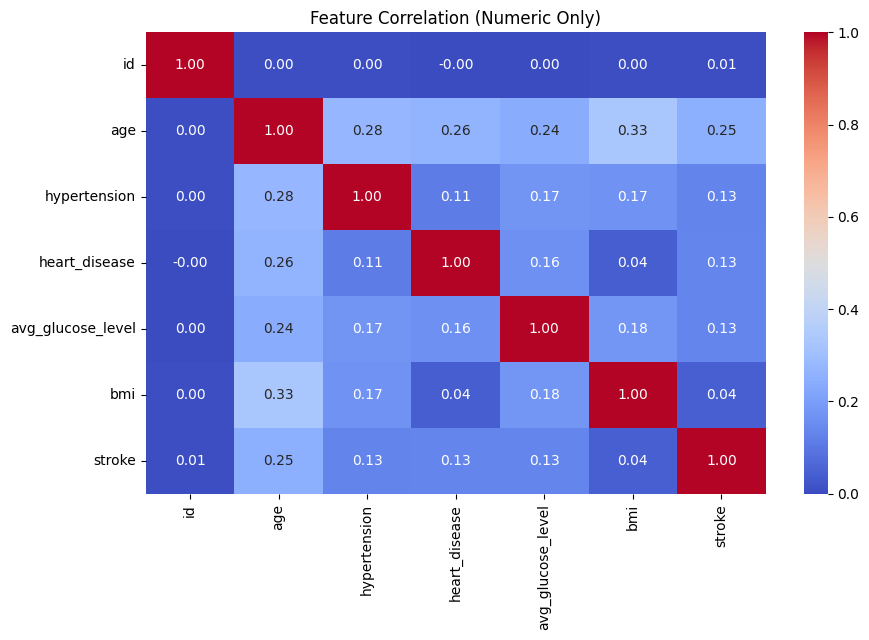

In [8]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation (Numeric Only)')
plt.show()

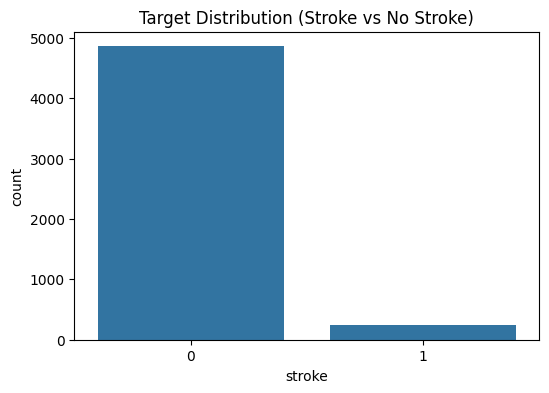

In [9]:
# Distribution of Target
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Target Distribution (Stroke vs No Stroke)')
plt.show()

In [11]:
# --- STEP 4: DATA PREPROCESSING ---
# 1. Drop the ID column (not a predictor)
df = df.drop('id', axis=1)

# 2. Handle Missing Values (BMI)
# The dataset often has 'N/A' or NaN. SimpleImputer fills these with the mean.
imputer = SimpleImputer(strategy='mean')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# 3. Clean Categorical Data
# Remove 'Other' from gender if it exists (usually only 1 instance)
df = df[df['gender'] != 'Other']

# 4. Encoding Categorical Data
# We use Label Encoding for simplicity across all 12 models
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
# --- STEP 5: TRAIN-TEST SPLIT (70:30) ---
X = df.drop('stroke', axis=1)
y = df['stroke']

# Standardize features (Crucial for KNN, SVM, and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed split applied to ALL models
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

In [13]:
# --- STEP 6: DEFINE THE 12 MODELS ---
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True), # probability=True required for AUC
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis()
}

In [14]:
# --- STEP 7: RUN MODELS AND EVALUATE ---
results_list = []

print("\n### Evaluating 12 Models... ###\n")

for name, model in models.items():
    # Fit the model on 70% training data
    model.fit(X_train, y_train)

    # Predict on 30% test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # 5-Fold Cross-Validation on the full training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "AUC Score": auc,
        "CV Mean Accuracy": cv_mean
    })
    print(f"Finished: {name}")


### Evaluating 12 Models... ###

Finished: Logistic Regression
Finished: K-Nearest Neighbors
Finished: Decision Tree
Finished: Random Forest
Finished: Support Vector Machine
Finished: Naive Bayes
Finished: Gradient Boosting
Finished: AdaBoost
Finished: Extra Trees


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:03:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Finished: XGBoost
Finished: Linear Discriminant Analysis
Finished: Quadratic Discriminant Analysis



### FINAL MODEL COMPARISON ###
                              Model  Accuracy  AUC Score  CV Mean Accuracy
7                          AdaBoost  0.941944   0.837981          0.955257
0               Logistic Regression  0.941944   0.837662          0.955257
6                 Gradient Boosting  0.942596   0.830706          0.951621
10     Linear Discriminant Analysis  0.938030   0.824893          0.947426
11  Quadratic Discriminant Analysis  0.870841   0.815579          0.879469
5                       Naive Bayes  0.856491   0.809354          0.872759
9                           XGBoost  0.939987   0.806312          0.946589
3                     Random Forest  0.939987   0.804795          0.954978
8                       Extra Trees  0.936725   0.768013          0.951901
4            Support Vector Machine  0.941944   0.638465          0.955257
1               K-Nearest Neighbors  0.940639   0.609123          0.954698
2                     Decision Tree  0.906067   0.554760          0.

/tmp/ipykernel_155/2397858193.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC Score', y='Model', data=results_df, palette='magma')


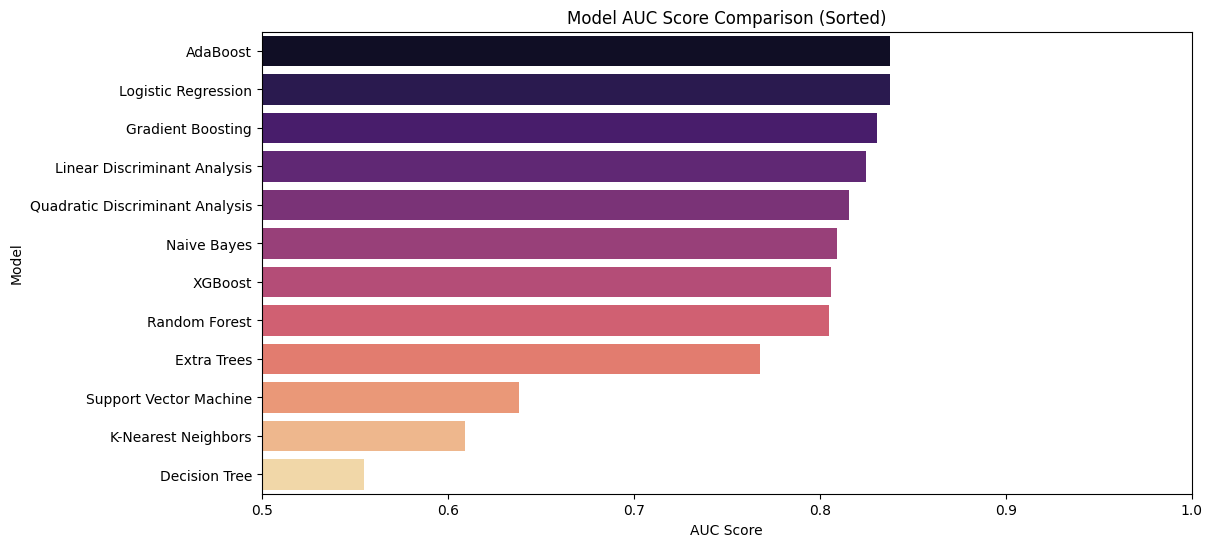

In [15]:
# --- STEP 8: FINAL RESULTS DISPLAY ---
results_df = pd.DataFrame(results_list).sort_values(by='AUC Score', ascending=False)

print("\n### FINAL MODEL COMPARISON ###")
print(results_df)

# Visualizing Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='AUC Score', y='Model', data=results_df, palette='magma')
plt.title('Model AUC Score Comparison (Sorted)')
plt.xlim(0.5, 1.0) # Zoom in to see differences
plt.show()